<a href="https://colab.research.google.com/github/HeyManan/Admin-Dashboard/blob/main/Hardware_Accelerators_Project_Group_11(GPU).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, lr_scheduler
from torch.utils.data import DataLoader, random_split
import random
import matplotlib.pyplot as plt
import os
import time
import pynvml

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [ ]:
seed = 42
torch.manual_seed(seed)
random.seed(seed)

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(32, scale=(0.9, 1.1)),
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])



val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

full_dataset = torchvision.datasets.GTSRB(root='./data', split='train', download=True)

split_ratio = 0.2
val_size = int(split_ratio * len(full_dataset))
train_size = len(full_dataset) - val_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])
train_data.dataset.transform = train_transform
val_data.dataset.transform = val_transform

batch_size = 64
trainloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=os.cpu_count(), pin_memory=True, persistent_workers=True)
valloader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count(), pin_memory=True, persistent_workers=True)

testset = torchvision.datasets.GTSRB(root='./data', split='test', download=True, transform=val_transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count(), pin_memory=True, persistent_workers=True)


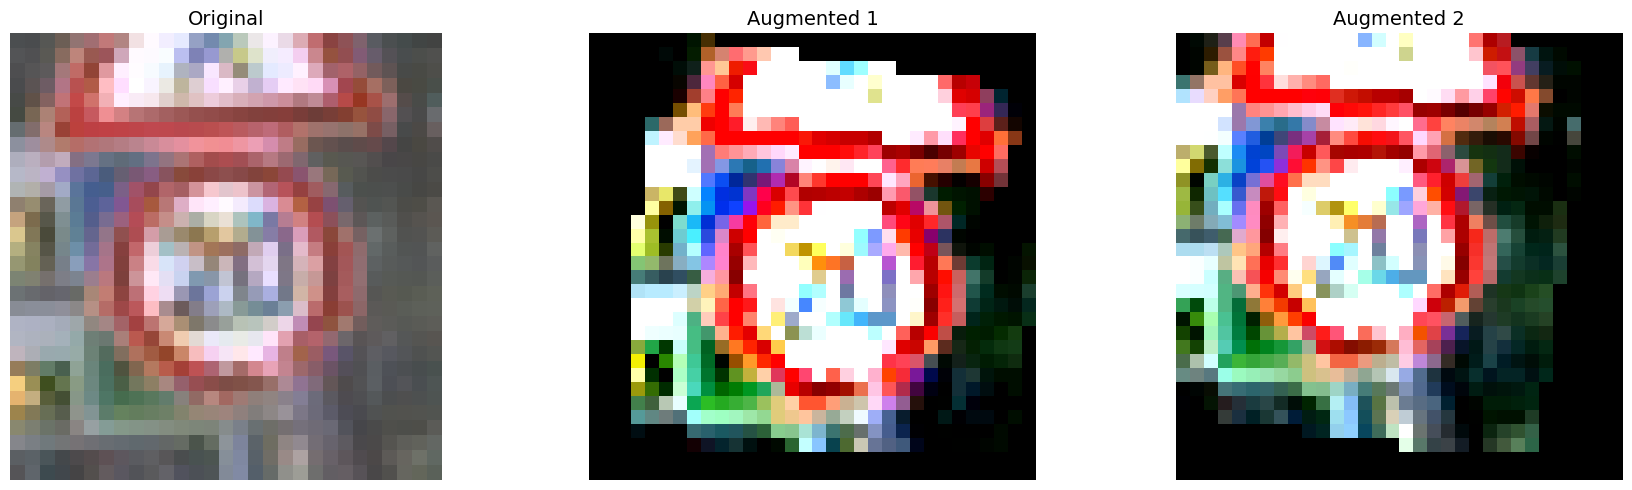

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load a clean sample
raw_dataset = torchvision.datasets.GTSRB(root='./data', split='train', download=True, transform=None)
sample_img, _ = raw_dataset[0]

# How many augmentations
num_augmented = 2

# Apply train_transform multiple times
augmented_imgs = [train_transform(sample_img) for _ in range(num_augmented)]

# Plot
fig, axes = plt.subplots(1, num_augmented + 1, figsize=(18, 5))

# Helper function to add border
def add_border(ax, color='black', linewidth=2):
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)

# Original Image
axes[0].imshow(sample_img)
axes[0].set_title('Original', fontsize=14)
axes[0].axis('off')
add_border(axes[0])

# Augmented Images
for idx, aug_img in enumerate(augmented_imgs):
    axes[idx + 1].imshow(aug_img.permute(1, 2, 0))  # (C, H, W) to (H, W, C)
    axes[idx + 1].set_title(f'Augmented {idx + 1}', fontsize=14)
    axes[idx + 1].axis('off')
    add_border(axes[idx + 1])

plt.tight_layout()
plt.show()


In [ ]:
class GPUModel(nn.Module):
    def __init__(self, output_dim):
        super(GPUModel, self).__init__()
        self.flatten = nn.Flatten()
        self.conv1 = nn.Conv2d(3, 64, 3, padding='same')
        self.conv2 = nn.Conv2d(64, 128, 3, padding='same')
        self.maxpool1 = nn.MaxPool2d(2)
        self.batchnorm1 = nn.BatchNorm2d(128)
        self.dropout1 = nn.Dropout(0.25)

        self.conv3 = nn.Conv2d(128, 256, 3, padding='same')
        self.conv4 = nn.Conv2d(256, 512, 3, padding='same')
        self.maxpool2 = nn.MaxPool2d(2)
        self.batchnorm2 = nn.BatchNorm2d(512)
        self.dropout2 = nn.Dropout(0.25)

        self.dense1 = nn.Linear(32768, 512)
        self.dense2 = nn.Linear(512, 128)
        self.dropout3 = nn.Dropout(0.2)
        self.dense3 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.maxpool1(x)
        x = self.batchnorm1(x)
        x = self.dropout1(x)

        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.maxpool2(x)
        x = self.batchnorm2(x)
        x = self.dropout2(x)

        x = self.flatten(x)
        x = self.relu(self.dense1(x))
        x = self.relu(self.dense2(x))
        x = self.dropout3(x)
        return self.dense3(x)

In [ ]:
class CPUModel(nn.Module):
    def __init__(self, output_dim):
        super(CPUModel, self).__init__()
        self.flatten = nn.Flatten()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.maxpool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.maxpool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)

        self.dense1 = nn.Linear(4096, 64)
        self.dropout = nn.Dropout(0.5)
        self.dense2 = nn.Linear(64, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.maxpool1(x)
        x = self.relu(self.conv2(x))
        x = self.maxpool2(x)
        x = self.relu(self.conv3(x))

        x = self.flatten(x)
        x = self.relu(self.dense1(x))
        x = self.dropout(x)
        return self.dense2(x)

In [ ]:
OUTPUT_DIM = 43
model = GPUModel(OUTPUT_DIM) if device.type == 'cuda' else CPUModel(OUTPUT_DIM)
model = model.to(device)

In [ ]:
from torchsummary import summary

def print_model_summary(model, input_size=(3, 32, 32)):
    print("Model Summary:")
    summary(model, input_size=input_size)

print_model_summary(model)

Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3          [-1, 128, 32, 32]          73,856
              ReLU-4          [-1, 128, 32, 32]               0
         MaxPool2d-5          [-1, 128, 16, 16]               0
       BatchNorm2d-6          [-1, 128, 16, 16]             256
           Dropout-7          [-1, 128, 16, 16]               0
            Conv2d-8          [-1, 256, 16, 16]         295,168
              ReLU-9          [-1, 256, 16, 16]               0
           Conv2d-10          [-1, 512, 16, 16]       1,180,160
             ReLU-11          [-1, 512, 16, 16]               0
        MaxPool2d-12            [-1, 512, 8, 8]               0
      BatchNorm2d-13            [-1, 512, 8, 8]           1,024
          Dropout-14    

In [ ]:
def train(model, trainloader, valloader, epochs=30, lr=0.0008):
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total

        val_loss, val_acc = evaluate(model, valloader, criterion)


        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {100*correct/total:.2f}% | Val Acc: {val_acc:.2f}%")
    return history

In [ ]:
def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(dataloader)
    val_acc = 100 * correct / total
    return val_loss, val_acc

history = train(model, trainloader, valloader)

Epoch 01 | Loss: 0.7282 | Train Acc: 79.67% | Val Acc: 98.16%
Epoch 02 | Loss: 0.0497 | Train Acc: 98.57% | Val Acc: 98.65%
Epoch 03 | Loss: 0.0384 | Train Acc: 98.93% | Val Acc: 99.08%
Epoch 04 | Loss: 0.0388 | Train Acc: 98.79% | Val Acc: 99.08%
Epoch 05 | Loss: 0.0252 | Train Acc: 99.30% | Val Acc: 99.61%
Epoch 06 | Loss: 0.0157 | Train Acc: 99.51% | Val Acc: 99.32%
Epoch 07 | Loss: 0.0217 | Train Acc: 99.39% | Val Acc: 99.51%
Epoch 08 | Loss: 0.0183 | Train Acc: 99.49% | Val Acc: 99.51%
Epoch 09 | Loss: 0.0179 | Train Acc: 99.50% | Val Acc: 99.59%
Epoch 10 | Loss: 0.0157 | Train Acc: 99.55% | Val Acc: 98.63%
Epoch 11 | Loss: 0.0070 | Train Acc: 99.79% | Val Acc: 99.89%
Epoch 12 | Loss: 0.0018 | Train Acc: 99.94% | Val Acc: 99.81%
Epoch 13 | Loss: 0.0012 | Train Acc: 99.94% | Val Acc: 99.79%
Epoch 14 | Loss: 0.0018 | Train Acc: 99.94% | Val Acc: 99.85%
Epoch 15 | Loss: 0.0038 | Train Acc: 99.88% | Val Acc: 99.91%
Epoch 16 | Loss: 0.0039 | Train Acc: 99.89% | Val Acc: 99.83%
Epoch 17

In [ ]:
test_loss, test_acc = evaluate(model, testloader, nn.CrossEntropyLoss())
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 96.30%


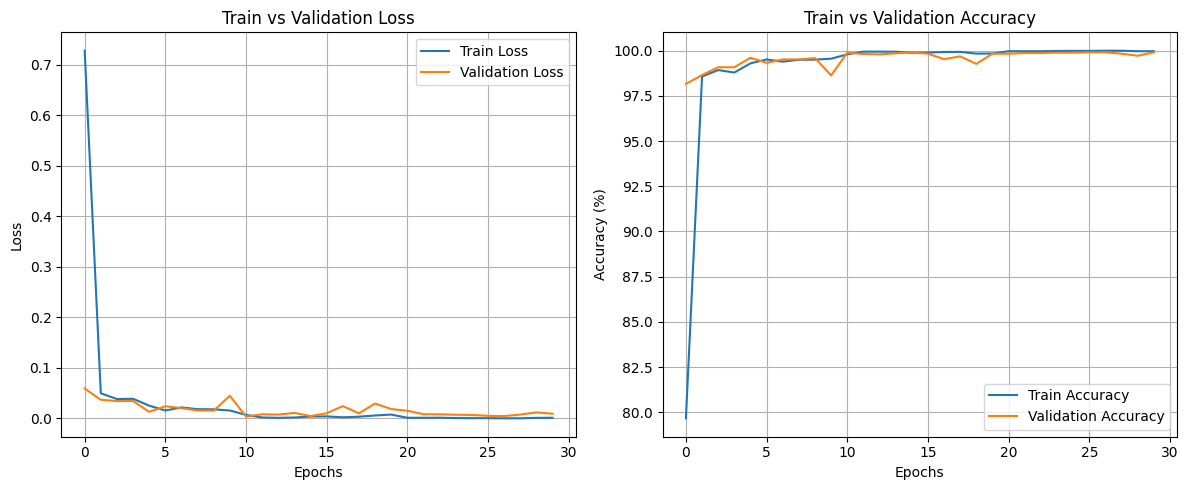

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# import psutil

# def measure_cpu_performance():
#     cpu_device = torch.device('cpu')
#     cpu_model = CPUModel(OUTPUT_DIM).to(cpu_device)
#     cpu_model.load_state_dict(model.state_dict())
#     cpu_model.eval()

#     process = psutil.Process(os.getpid())
#     cpu_times_before = process.cpu_times()
#     start_time = time.time()
#     acc = evaluate(cpu_model, testloader, nn.CrossEntropyLoss())
#     end_time = time.time()
#     cpu_times_after = process.cpu_times()

#     elapsed = end_time - start_time
#     user_time = cpu_times_after.user - cpu_times_before.user
#     system_time = cpu_times_after.system - cpu_times_before.system
#     cpu_power_estimate = (user_time + system_time) / elapsed  # proxy

#     print(f"\nCPU Inference Time: {elapsed:.2f} seconds")
#     print(f"CPU Test Accuracy: {acc:.2f}%")
#     print(f"CPU Proxy Power Usage: {cpu_power_estimate:.2f} units (user+system time / elapsed)")
#     print("Note: For actual energy/power, use Intel RAPL, Powerstat, or external sensors.")

In [ ]:
# if device.type == 'cpu':
#     measure_cpu_performance()

In [ ]:
def measure_gpu_performance():
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    start_energy = pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)
    start_time = time.time()
    model.to(device)
    model.eval()
    _, acc = evaluate(model, testloader, nn.CrossEntropyLoss())
    end_time = time.time()
    end_energy = pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)
    runtime = end_time - start_time
    energy = (end_energy - start_energy) / 1000

    macs = 473439531
    gops = macs * len(testloader) / (1024**3)
    throughput = gops / runtime
    energy_eff = throughput / energy if energy > 0 else 0

    print(f"\nGPU Runtime: {runtime:.2f}s")
    print(f"GPU Energy: {energy:.4f}J")
    print(f"GPU Test Accuracy: {acc:.2f}%")
    print(f"Throughput: {throughput:.2f} GOPS")
    print(f"Energy Efficiency: {energy_eff:.2f} GOPS/W")

if device.type == 'cuda':
    measure_gpu_performance()



GPU Runtime: 3.89s
GPU Energy: 138.2050J
GPU Test Accuracy: 0.89%
Throughput: 22.45 GOPS
Energy Efficiency: 0.16 GOPS/W


In [ ]:
!pip install nvidia-ml-py
import psutil
import pynvml

iterations = 2500
image = testset[0][0].unsqueeze(0);

def get_gpu_info():
  UNIT = 1024 * 1024;
  pynvml.nvmlInit();

  gpuDeviceCount = pynvml.nvmlDeviceGetCount();
  handle = pynvml.nvmlDeviceGetHandleByIndex(0);
  memoryInfo = pynvml.nvmlDeviceGetMemoryInfo(handle);
  gpuTemperature = pynvml.nvmlDeviceGetTemperature(handle, 0);
  gpuPowerState = pynvml.nvmlDeviceGetPowerUsage(handle);

  print("GPU Name:", pynvml.nvmlDeviceGetName(handle));
  print("Number of GPU：", gpuDeviceCount);
  print("Memory (Total):", memoryInfo.total/UNIT, "MB");
  print("Memory (Used):", memoryInfo.used/UNIT, "MB");
  print("Memory (free):", memoryInfo.free/UNIT, "MB");
  print("GPU Temperature:", gpuTemperature, "C");
  print("GPU Power Usage:", gpuPowerState/(10**3), "W");

def get_current_energy():
  pynvml.nvmlInit()
  handle = pynvml.nvmlDeviceGetHandleByIndex(0)
  gpuEnergyUsage = pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)
  return gpuEnergyUsage


def print_eval(macs,time_start,time_end,energy_start=0,energy_end=0):
  total_energy = energy_end - energy_start;
  total_time = time_end - time_start;

  gop = (macs * len(testloader)) / (1024**3);

  print("Energy:", total_energy * (10**-3), "J");
  print("Time:", total_time, "s");
  print("Throughput:", gop / total_time, "GOPS");
  if(total_energy!=0):
    print("Energy Efficiency:", (gop / total_time) / (total_energy * (10**-3)), "GOPS/W");

def performance_evaluation_float32(network, macs):
  # network.type(torch.float);
  # imagex = image.type(torch.float);
  # imagex = image.to(device);
  network = network.to(device)
  network.eval();

  energy_start = get_current_energy();
  time_start = time.time();

  # for i in range(iterations):
  _, acc = evaluate(network, testloader, nn.CrossEntropyLoss())


  time_end = time.time();
  energy_end = get_current_energy();

  print("FOR", type(network).__name__, ":");
  print_eval(macs,time_start,time_end,energy_start,energy_end);
  print("\n");

def performance_evaluation_cpu(network, macs):
  network.type(torch.float);
  imagex = image.type(torch.float);
  imagex = image.to(device);
  network = network.to(device)
  network.eval();

  # energy_start = get_current_energy();
  time_start = time.time();

  for i in range(iterations):
    output = network(imagex);

  time_end = time.time();
  # energy_end = get_current_energy();

  print("FOR", type(network).__name__, ":");
  print_eval(macs,time_start,time_end,0,0);
  print("\n");

In [ ]:
!pip install ptflops
from ptflops import get_model_complexity_info

# Example for GPUModel
model = GPUModel(output_dim=43)

# Input size = (channels, height, width), usually (3, 32, 32) for traffic signs
gmacs, gparams = get_model_complexity_info(model, (3, 32, 32), as_strings=False,
                                         print_per_layer_stat=True, verbose=True)

print(f"\nGPUModel: MACs = {gmacs}, Parameters = {gparams}")

# Similarly for CPUModel
model = CPUModel(output_dim=43)
cmacs, cparams = get_model_complexity_info(model, (3, 32, 32), as_strings=False,
                                         print_per_layer_stat=True, verbose=True)

print(f"\nCPUModel: MACs = {cmacs}, Parameters = {cparams}")


GPUModel(
  18.4 M, 100.000% Params, 472.78 MMac, 99.861% MACs, 
  (flatten): Flatten(0, 0.000% Params, 0.0 Mac, 0.000% MACs, start_dim=1, end_dim=-1)
  (conv1): Conv2d(1.79 k, 0.010% Params, 1.84 MMac, 0.388% MACs, 3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv2): Conv2d(73.86 k, 0.401% Params, 75.63 MMac, 15.974% MACs, 64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (maxpool1): MaxPool2d(0, 0.000% Params, 131.07 KMac, 0.028% MACs, kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (batchnorm1): BatchNorm2d(256, 0.001% Params, 65.54 KMac, 0.014% MACs, 128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(0, 0.000% Params, 0.0 Mac, 0.000% MACs, p=0.25, inplace=False)
  (conv3): Conv2d(295.17 k, 1.604% Params, 75.56 MMac, 15.960% MACs, 128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv4): Conv2d(1.18 M, 6.413% Params, 302.12 MMac, 63.814% MACs, 256, 512, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
if device.type == 'cuda':
  get_gpu_info()
  performance_evaluation_float32(GPUModel(OUTPUT_DIM), gmacs)
else:
  performance_evaluation_cpu(CPUModel(OUTPUT_DIM), cmacs)

GPU Name: Tesla T4
Number of GPU： 1
Memory (Total): 15360.0 MB
Memory (Used): 1303.875 MB
Memory (free): 14056.125 MB
GPU Temperature: 76 C
GPU Power Usage: 34.396 W
FOR GPUModel :
Energy: 241.072 J
Time: 3.9698431491851807 s
Throughput: 21.991582906538955 GOPS
Energy Efficiency: 0.09122412767363673 GOPS/W


